# Introduction

In part 1 of this assessment, you will complete several requested SQL queries in order to extract data, analyze, and provide insights from a single provided SQL database. You will also visualize the key results of 3 of these queries. There are also several 'Reflection' questions that ask you to write out a text based answer in the provided markdown cell. Following the guided question and answer section, in part 2 you will explore a second dataset on your own using SQL in order to conduct a preliminary analysis. You will be asked to produce a very short slide presentation highlighting the work you did for this second section.

## Objectives
You will be able to:
- Interpret "word problems" and translate them into SQL queries
- Decide and perform whichever type of JOIN is best for retrieving desired data
- Use GROUP BY statements to apply aggregate functions like COUNT, MAX, MIN, and SUM
- Use the HAVING clause to compare different aggregates
- Write subqueries to decompose complex queries
- Visualize data using matplotlib, seaborn, or pandas
- Choose the correct chart type based on the given data


## Part 1: Guided SQL Queries

### Your Task: Querying a Customer Database

![toy car picture](images/toycars.jpg)


### Business Understanding
Your employer sells wholesale miniature models of products such as classic cars, motorcycles, and planes. They want you to pull several reports on different segments of their past customers, in order to better understand past sales as well as determine which customers will receive promotional material. They are also interested in investigating which products have performed the best, as well as having several smaller asks.

In addition to providing the requested data from the SQL database you have also been asked to create some basic visuals to display some of the more insightful information. It is up to your discretion to choose the correct plot/chart type for the data in question. **Questions that want you to visualize the results will be explicitly marked**.

### Data Understanding
You may remember this database from a previous lab. As a refresher, here's the ERD diagram for this database:

![ERD picture](images/ERD.png)

The queries you are asked to write will become more complex over the course of the lab.



### Getting Started
For this assessment you are expected to make use of both sqlite3 and the Pandas libraries in order to write, execute, and return SQL queries as a Pandas DataFrame. Assign each returned answer as its own explicit variable.

For the visualization piece you are expected to utilize either Pandas, Seaborn, or Matplotlib to create your visuals. Make sure you are providing verbose labels and titles according to the data you are being asked to visualize. Do not worry too much about choosing a 'style' or 'context' instead focus on conveying the requested information correctly.

### Step 1: Connect to Data

In the cell below
- Import the necessary libraries
- Establish a connection to the database data.sqlite

In [167]:
# Imports
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create connection to database
conn = sqlite3.connect('data.sqlite')

### Step 2: Limited Edition California Product
The California sales rep team is interested in running promotional material for a new limited edition model they are releasing based on the famous San Francisco Cable Cars. This product will only be available to customer stores based in California and given its high price value they want to first target promotional material to existing California customers with a high credit limit. Upon communicating with the accounting department, a credit limit of over 25,000 is considered to be high. 

Execute a SQl query that returns which customers the sales rep team wants to market to first.

In [168]:
# Step 2: Customers in California with credit limit over 25,000
step2_df = pd.read_sql("""
    SELECT customerNumber, customerName, contactFirstName, contactLastName,city, state, creditLimit
    FROM customers
    WHERE country = 'USA'
      AND state = 'CA'
      AND creditLimit > 25000
    ORDER BY creditLimit DESC
""", conn)

step2_df

,customerNumber,customerName,contactFirstName,contactLastName,city,state,creditLimit
0,205,Toys4GrownUps.com,Julie,Young,Pasadena,CA,90700.00
1,161,Technics Stores Inc.,Juri,Hashimoto,Burlingame,CA,84600.00
2,450,The Sharp Gifts Warehouse,Sue,Frick,San Jose,CA,77600.00
3,129,Mini Wheels Co.,Julie,Murphy,San Francisco,CA,64600.00
4,487,Signal Collectibles Ltd.,Sue,Taylor,Brisbane,CA,60300.00
5,347,"Men 'R' US Retailers, Ltd.",Brian,Chandler,Los Angeles,CA,57700.00
6,475,West Coast Collectables Co.,Steve,Thompson,Burbank,CA,55400.00
7,124,Mini Gifts Distributors Ltd.,Susan,Nelson,San Rafael,CA,210500.00
8,219,Boards & Toys Co.,Mary,Young,Glendale,CA,11000.00
9,239,Collectable Mini Designs Co.,Valarie,Thompson,San Diego,CA,105000.00


### Step 3: International Collectable Campaign

The international sales rep team has reached out to you to help them identify partners for a 'Collectable' marketing campaign that highlights the potential collectors value in purchasing these model kits. They want to try and promote a 'collect them all' mentality. The team had a great idea to partner with any of their international customers (non-US) who have "Collect" in their name as a tie in to the larger theme.

Execute a SQL that returns the customers in question.

In [169]:
# Step 3: International customers (non-USA) with 'Collect' in their name
step3_df = pd.read_sql("""
    SELECT customerNumber, customerName, contactFirstName, contactLastName, city, country
    FROM customers
    WHERE country != 'USA'
      AND customerName LIKE '%Collect%'
""", conn)

step3_df

,customerNumber,customerName,contactFirstName,contactLastName,city,country
0,114,"Australian Collectors, Co.",Peter,Ferguson,Melbourne,Australia
1,189,"Clover Collections, Co.",Dean,Cassidy,Dublin,Ireland
2,201,"UK Collectables, Ltd.",Elizabeth,Devon,Liverpool,UK
3,211,"King Kong Collectables, Co.",Mike,Gao,Central Hong Kong,Hong Kong
4,227,Heintze Collectables,Palle,Ibsen,Århus,Denmark
5,260,"Royal Canadian Collectables, Ltd.",Elizabeth,Lincoln,Tsawassen,Canada
6,293,BG&E Collectables,Ed,Harrison,Fribourg,Switzerland
7,353,Reims Collectables,Paul,Henriot,Reims,France
8,376,Precious Collectables,Braun,Urs,Bern,Switzerland
9,382,Salzburg Collectables,Georg,Pipps,Salzburg,Austria


## Reflection Question:

Describe the WHERE clause you used in the above query to a non-technical manager who wants to be ensured that you are properly filtering and only selecting the requested data. How is the operator and conditional expression you are using acting to accomplish this?

## Answer:

The WHERE clause is doing two things at once to make sure we only return the right customers. First, `country != 'USA'` removes any US-based customers — the `!=` operator means 'does not equal', so only international customers pass through. Second, `customerName LIKE '%Collect%'` checks whether the word 'Collect' appears anywhere in the customer's name. The `LIKE` operator is used for pattern matching, and the `%` symbols act as wildcards — meaning there can be any amount of text before or after the word 'Collect'. Together, both conditions must be true for a customer to appear in the results, which ensures we are only targeting international partners whose name includes the word 'Collect'.

### Step 4: USA Credit and Inventory Policy - Visual Required
The USA based product team is planning to adjust its credit policies and inventory allocation strategy based on the average credit limit of its customers. They would like to target this strategy at a state level with several goals in mind. 
1. Optimize inventory distribution:
    - States with higher average credit limits might be able to place larger orders, justifying priority in inventory allocation.
    - This could help ensure that states with more purchasing power always have products in stock.
2. Tailor credit policies:
    - Adjust credit limits for new customers based on the state average.
    - Identify states where they might be too conservative or too liberal with credit limits.
3. Target marketing and sales efforts:
    - Focus promotional campaigns on states with higher credit limits, potentially leading to larger orders.
    - Develop strategies to increase sales in states with lower average credit limits.

Execute a SQl query that returns the information required to address this ask.

In [170]:
# Step 4: Average credit limit by US state
step4_df = pd.read_sql("""
    SELECT state, ROUND(AVG(creditLimit), 2) AS avg_credit_limit
    FROM customers
    WHERE country = 'USA'
      AND state IS NOT NULL
    GROUP BY state
    ORDER BY avg_credit_limit DESC
""", conn)

step4_df

,state,avg_credit_limit
0,NH,114200.00
1,NY,89966.67
2,PA,84766.67
3,CA,83854.55
4,NV,71800.00
5,MA,70755.56
6,CT,57350.00
7,NJ,43000.00


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

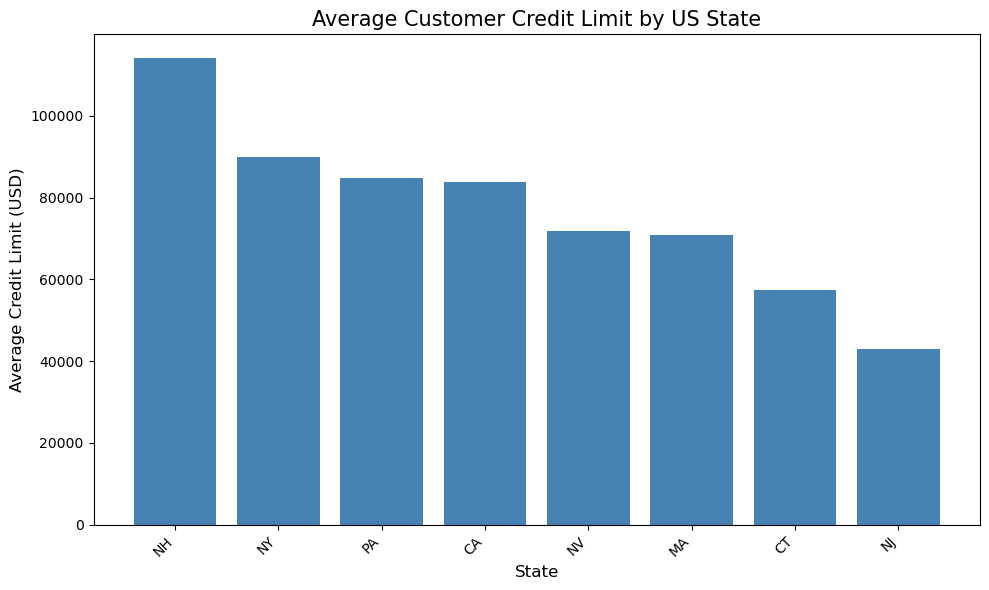

In [171]:
# Visualization: Average credit limit by US state
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(step4_df['state'], step4_df['avg_credit_limit'], color='steelblue')

ax.set_title('Average Customer Credit Limit by US State', fontsize=15)
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Average Credit Limit (USD)', fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Step 5: Top Customers - Visual Required
The company is approaching its 10 year anniversary and wants to acknowledge and thank its top customers with personalized communication. They have asked you to determine the top 10 customers based on the total amount of payments made, making sure to return the customer name for clarity. 

Execute a SQl query that returns the information required to address this ask.


In [172]:
# Step 5: Top 10 customers by total payment amount
step5_df = pd.read_sql("""
    SELECT c.customerName, ROUND(SUM(p.amount), 2) AS total_payments
    FROM customers c
    JOIN payments p ON c.customerNumber = p.customerNumber
    GROUP BY c.customerNumber
    ORDER BY total_payments DESC
    LIMIT 10
""", conn)

step5_df

,customerName,total_payments
0,Euro+ Shopping Channel,715738.98
1,Mini Gifts Distributors Ltd.,584188.24
2,"Australian Collectors, Co.",180585.07
3,Muscle Machine Inc,177913.95
4,"Dragon Souveniers, Ltd.",156251.03
5,"Down Under Souveniers, Inc",154622.08
6,"AV Stores, Co.",148410.09
7,"Anna's Decorations, Ltd",137034.22
8,Corporate Gift Ideas Co.,132340.78
9,"Saveley & Henriot, Co.",130305.35


Once you have the information returned in a dataframe, select an appropriate visualization to represent this data. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

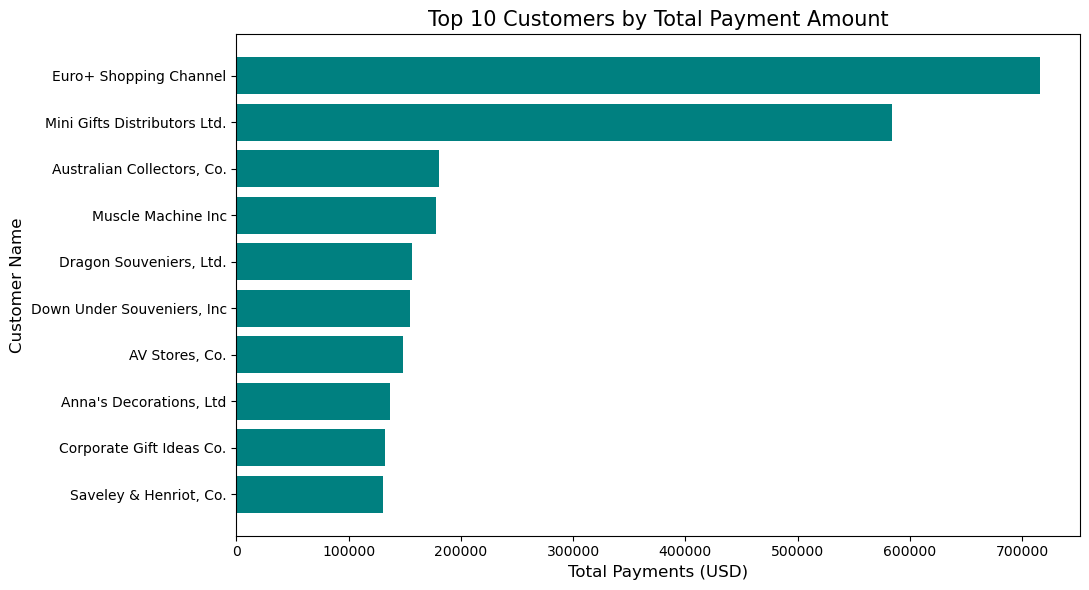

In [173]:
# Visualization: Top 10 customers by total payments
fig, ax = plt.subplots(figsize=(11, 6))

ax.barh(step5_df['customerName'], step5_df['total_payments'], color='teal')

ax.set_title('Top 10 Customers by Total Payment Amount', fontsize=15)
ax.set_xlabel('Total Payments (USD)', fontsize=12)
ax.set_ylabel('Customer Name', fontsize=12)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Step 6: Top Customer + Product Quantities
The product team is running an analysis on popular and common products sold to each customer in order to try and determine what new products they should be looking at to include in their catalog. This data will also be used by individual sales reps to recommend similar products to each customer next time they place an order. 

They have asked you to query information, for each customer, about any product they have purchased 10 or more units of. In addition they would like the full set of data to be sorted in ascending order by the total amount purchased.

Execute a SQl query that returns the information required to address this ask.

Hint: For this one, you'll need to make use of HAVING, GROUP BY, and ORDER BY — make sure you get the order of them correct!

In [174]:
# Step 6: Products each customer ordered 10 or more units of, sorted by total quantity ascending
step6_df = pd.read_sql("""
    SELECT c.customerName, p.productName, SUM(od.quantityOrdered) AS total_quantity
    FROM customers c
    JOIN orders o ON c.customerNumber = o.customerNumber
    JOIN orderdetails od ON o.orderNumber = od.orderNumber
    JOIN products p ON od.productCode = p.productCode
    GROUP BY c.customerNumber, p.productCode
    HAVING total_quantity >= 10
    ORDER BY total_quantity ASC
""", conn)

step6_df

,customerName,productName,total_quantity
0,Petit Auto,1913 Ford Model T Speedster,10
1,"Extreme Desk Decorations, Ltd",1961 Chevrolet Impala,10
2,La Rochelle Gifts,1954 Greyhound Scenicruiser,11
3,Tekni Collectables Inc.,American Airlines: B767-300,11
4,The Sharp Gifts Warehouse,1969 Chevrolet Camaro Z28,13
...,...,...,...
2526,Euro+ Shopping Channel,2002 Chevy Corvette,174
2527,Euro+ Shopping Channel,1957 Chevy Pickup,183
2528,Euro+ Shopping Channel,1970 Dodge Coronet,197
2529,Euro+ Shopping Channel,1958 Chevy Corvette Limited Edition,245


### Step 7: Product Analysis - Visual Required

The product team is looking into the demand across its different product lines. They are conducting a comprehensive review of its product portfolio and inventory management strategies. You have been asked to query data pertaining to each different product line, that contains the total quantity ordered and the total number of products for each respective product line. By examining the number of products and total quantity ordered for each product line, the company aims to:
1. Optimize product mix:
    - Identify which product lines have the most diverse offerings (high number of products)
    - Determine which lines are most popular (high total quantity ordered)
    - Compare if lines with more products necessarily lead to more orders
2. Improve inventory management:
    - Adjust stock levels based on the popularity of each product line
    - Identify potential overstocking in lines with low order quantities
    - Ensure adequate variety in high-performing product lines
3. Adjust marketing strategy:
    - Focus promotional efforts on product lines with high potential (many products but lower order quantities)
    - Capitalize on the popularity of high-performing lines in marketing campaigns
4. Advise Product development:
    - Invest in expanding product ranges for lines with high order quantities
    - Consider phasing out or revamping product lines with low numbers of products and low order quantities

Hint: Think about how you can and might have to utilize SQL DISTINCT statement

Execute a SQl query that returns the information required to address this ask.

In [175]:
# Step 7: Total quantity ordered and number of distinct products per product line
step7_df = pd.read_sql("""
    SELECT p.productLine,
           COUNT(DISTINCT p.productCode) AS num_products,
           SUM(od.quantityOrdered) AS total_quantity_ordered
    FROM products p
    JOIN orderdetails od ON p.productCode = od.productCode
    GROUP BY p.productLine
    ORDER BY total_quantity_ordered DESC
""", conn)

step7_df

,productLine,num_products,total_quantity_ordered
0,Classic Cars,37,35582
1,Vintage Cars,24,22933
2,Motorcycles,13,12778
3,Planes,12,11872
4,Trucks and Buses,11,11001
5,Ships,9,8532
6,Trains,3,2818


Once you have the information returned in a dataframe, select an appropriate visualization to represent the relationship between total quantity ordered and the number of products in order to perform a preliminary investigation into the question of if more products lead to more orders. You are welcome to utilize matplotlib, seaborn, or pandas plotting to produce your visual. Ensure that it has a verbose title and axis labels!

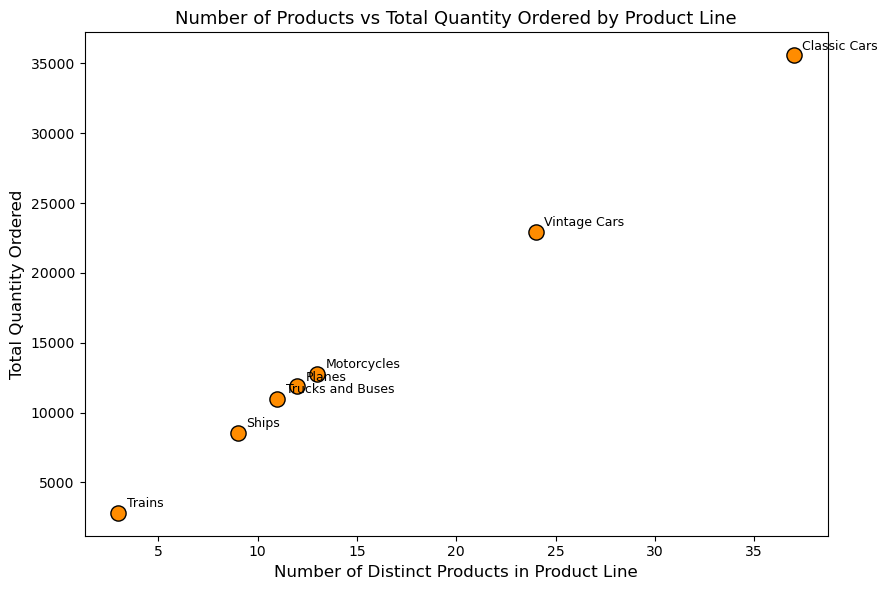

In [176]:
# Visualization: Number of products vs total quantity ordered by product line
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(step7_df['num_products'], step7_df['total_quantity_ordered'],
           color='darkorange', s=120, edgecolors='black')

# Label each point with the product line name
for i, row in step7_df.iterrows():
    ax.annotate(row['productLine'],
                (row['num_products'], row['total_quantity_ordered']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.set_title('Number of Products vs Total Quantity Ordered by Product Line', fontsize=13)
ax.set_xlabel('Number of Distinct Products in Product Line', fontsize=12)
ax.set_ylabel('Total Quantity Ordered', fontsize=12)

plt.tight_layout()
plt.show()

## Reflection Question:

Please explain your choice in the type of visual you used in order to highlight and represent the data from the above query. In a non-technical manner explain why that chart type makes sense for the information being conveyed. What does this visual convey in the context of the question it was asked for?

## Answer:

I chose a **scatter plot** for this visualization because we are comparing two separate numeric values for each product line — the number of products it contains, and the total quantity ordered. A scatter plot places each product line as a single dot on the chart, and the position of that dot tells you both pieces of information at the same time: how far left or right it sits shows the number of products, and how high or low it sits shows the total orders.

This is a good chart type here because we are trying to see if there is a relationship between those two numbers — specifically, does a product line with more products tend to get more orders? A bar chart could show one value at a time, but a scatter plot lets you spot patterns between two variables at a glance. In this case, the chart shows that having more products in a line does not automatically mean more units are ordered — for example, Classic Cars has a relatively small catalog but leads in total orders, which tells the product team that quality and demand matter more than sheer variety.

### Step 8: Remote Offices
Upper management is considering a shift to hybrid and remote work for certain locations and roles. They have tasked you with providing them data about employees who work in any office that has fewer than 5 total employees so they can better understand how to support those employees remotely when offices are shut down. 

Be sure to include information about the employees job and supervisor so management can adjust everyone to remote work properly.

Hint: Utilize a subquery to find the relevant offices

Execute a SQl query that returns the information required to address this ask.

In [177]:
# Step 8: Employees who work in offices with fewer than 5 employees
# The subquery first finds which office codes have fewer than 5 employees,
# then the main query returns employee details for those offices.
step8_df = pd.read_sql("""
    SELECT e.firstName, e.lastName, e.jobTitle, e.reportsTo, e.officeCode
    FROM employees e
    WHERE e.officeCode IN (
        SELECT officeCode
        FROM employees
        GROUP BY officeCode
        HAVING COUNT(employeeNumber) < 5
    )
    ORDER BY e.officeCode, e.lastName
""", conn)

step8_df

,firstName,lastName,jobTitle,reportsTo,officeCode
0,Julie,Firrelli,Sales Rep,1143,2
1,Steve,Patterson,Sales Rep,1143,2
2,Foon Yue,Tseng,Sales Rep,1143,3
3,George,Vanauf,Sales Rep,1143,3
4,Yoshimi,Kato,Sales Rep,1621,5
5,Mami,Nishi,Sales Rep,1056,5
6,Andy,Fixter,Sales Rep,1088,6
7,Tom,King,Sales Rep,1088,6
8,Peter,Marsh,Sales Rep,1088,6
9,William,Patterson,Sales Manager (APAC),1056,6


## Reflection Question:

Describe how you decided on the subquery that you used in the query above? This answer can be technically in nature, describing your thought process in how the main query is utilizing the subquery to return the correct data.

## Answer:

I broke the problem into two smaller questions. The first question was: which offices have fewer than 5 employees? To answer that on its own, I knew I needed to count employees grouped by office, and then use HAVING to filter for offices where that count is below 5. That logic became my subquery: it runs on the employees table, groups by officeCode, and returns only the office codes that meet the condition.

The second question was: once I know those office codes, how do I get the employee details? That became the main (outer) query. I used `WHERE e.officeCode IN (...)` so that the main query only keeps employees whose office code matches one of the results from the subquery. The subquery runs first and produces a list of qualifying office codes, and then the main query uses that list as a filter. This approach is clean because it keeps the 'find small offices' logic separate from the 'return employee details' logic, making it easier to read and debug.

### Step 9: Close the Connection

Now that you are finished executing your queries and retrieving the required information you always want to make sure to close the connection to your database.

In [178]:
# Close the connection to the database
conn.close()
print('Connection closed.')

Connection closed.


### End of Guided Section
In this initial portion of the assessment, you produced several data queries and visualizations for a model company, mainly focused around its customer and product data. You wrote and engineered specific SQL queries to address pertinent questions and asks from the company. Along the way, you utilized many of the major concepts and keywords associated with SQL SELECT queries: FROM, WHERE, GROUP BY, HAVING, ORDER BY, JOIN, SUM, COUNT, and AVG.

## Part 2: Exploratory Analysis with SQL
In this open-ended exploratory section, you will analyze real-world data from the movie industry. As a data analyst, you have the freedom to investigate questions and topics that intrigue you within this dataset. The database schema and Entity-Relationship Diagram (ERD) are provided below for your reference. A general overview and instructions are also provided below.

In [179]:
# Run this cell without changes
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

# Only extract if the zip file exists
import os
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect('im.db')

# Schema
schema_df = pd.read_sql("""
SELECT * FROM sqlite_master
""", conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


## The Data

![movie ERD](images/movie_data_erd.jpeg)
### Database Content:

- Source: IMDB
- Time Range: Movies released between 2010 and 2019
- Note: Exclude any movies with a start_year after 2019 as this data is not current or accurate

Available Data Categories:
- Genre
- Runtime
- Personnel (writers, directors, actors)
- Movie ratings

### Objectives:

Initial Exploration:
- Use SQL in combination with Pandas to explore the database
- Identify interesting trends, patterns, or relationships in the data

Business Question Formulation:
- Develop at least one substantial business question for deeper analysis
- Ensure the question is relevant, specific, and can be addressed with the available data

Data Cleaning Assessment:
- Identify potential data cleaning tasks necessary for your deeper analysis
- Note: You are not required to perform the cleaning, only to recognize and list the necessary tasks

Null Value Handling:
- Be aware that the dataset contains null values in certain fields
- Exclude these null values from your exploration
- Do not attempt to input or fill in missing information

### Deliverables:

You need to produce a short slide presentation (3-5 slides) that highlights the three key deliverables below. Utilize a data visualization to support the second deliverable.

1. A summary of your initial data exploration findings
    - Can be bulleted or sentence form
2. At least one well-formulated business question for further analysis
    - Should stem from a relevant trend or pattern your initial exploration identified
3. A list of potential data cleaning tasks identified during your exploration
    - This can and should include things like data normalization/standardization and null handling

Tips for Success:

Begin with broad exploratory queries to understand the data's scope and content. Then focus on honing in on interesting relationships between different data categories. Consider industry trends, audience preferences, or financial aspects when formulating your business question. Pay attention to data quality issues, inconsistencies, or limitations that might affect your analysis. Remember, the goal is to demonstrate your analytical thinking and ability to derive meaningful insights from complex datasets. Good luck with your exploration!

NOTE: You do not need to explore every aspect of this database. Find something that you think is interesting or relevant about the data and focus your exploration there.

In [180]:
# Run this cell without changes
import zipfile

zip_file_path = 'im.db.zip'
extract_to_path = './'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to_path)

# Connection
conn4 = sqlite3.connect('im.db')

# Schema
schema_df = pd.read_sql("""
SElECT * FROM sqlite_master                        
""", conn4)
schema_df

,type,name,tbl_name,rootpage,sql
0,table,movie_basics,movie_basics,2,"CREATE TABLE ""movie_basics"" (\n""movie_id"" TEXT..."
1,table,directors,directors,3,"CREATE TABLE ""directors"" (\n""movie_id"" TEXT,\n..."
2,table,known_for,known_for,4,"CREATE TABLE ""known_for"" (\n""person_id"" TEXT,\..."
3,table,movie_akas,movie_akas,5,"CREATE TABLE ""movie_akas"" (\n""movie_id"" TEXT,\..."
4,table,movie_ratings,movie_ratings,6,"CREATE TABLE ""movie_ratings"" (\n""movie_id"" TEX..."
5,table,persons,persons,7,"CREATE TABLE ""persons"" (\n""person_id"" TEXT,\n ..."
6,table,principals,principals,8,"CREATE TABLE ""principals"" (\n""movie_id"" TEXT,\..."
7,table,writers,writers,9,"CREATE TABLE ""writers"" (\n""movie_id"" TEXT,\n ..."


In [181]:

# EXPLORATION 1: How many movies are in the dataset? 
explore1_df = pd.read_sql("""
    SELECT COUNT(*) AS total_movies
    FROM movie_basics
    WHERE start_year BETWEEN 2010 AND 2019
""", conn4)

print('Total movies in dataset (2010-2019):')
explore1_df

Total movies in dataset (2010-2019):


,total_movies
0,145081


In [182]:
# EXPLORATION 2: Movie count by year 
explore2_df = pd.read_sql("""
    SELECT start_year, COUNT(*) AS num_movies
    FROM movie_basics
    WHERE start_year BETWEEN 2010 AND 2019
    GROUP BY start_year
    ORDER BY start_year
""", conn4)

explore2_df

,start_year,num_movies
0,2010,11849
1,2011,12900
2,2012,13787
3,2013,14709
4,2014,15589
5,2015,16243
6,2016,17272
7,2017,17504
8,2018,16849
9,2019,8379


In [183]:
# EXPLORATION 3: Average rating by single genre (2010-2019) 
# Only looking at movies with a single genre (no comma) for cleaner grouping
explore3_df = pd.read_sql("""
    SELECT mb.genres,
           ROUND(AVG(mr.averagerating), 2) AS avg_rating,
           COUNT(mb.movie_id) AS num_movies
    FROM movie_basics mb
    JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
    WHERE mb.start_year BETWEEN 2010 AND 2019
      AND mb.genres IS NOT NULL
      AND mr.averagerating IS NOT NULL
      AND mb.genres NOT LIKE '%,%'
    GROUP BY mb.genres
    HAVING COUNT(mb.movie_id) > 200
    ORDER BY avg_rating DESC
""", conn4)

explore3_df

,genres,avg_rating,num_movies
0,Documentary,7.29,10313
1,Drama,6.49,11612
2,Family,6.08,491
3,Romance,6.05,717
4,Crime,5.92,268
5,Animation,5.91,348
6,Comedy,5.78,5613
7,Action,5.76,979
8,Thriller,5.70,1555
9,Sci-Fi,5.44,295


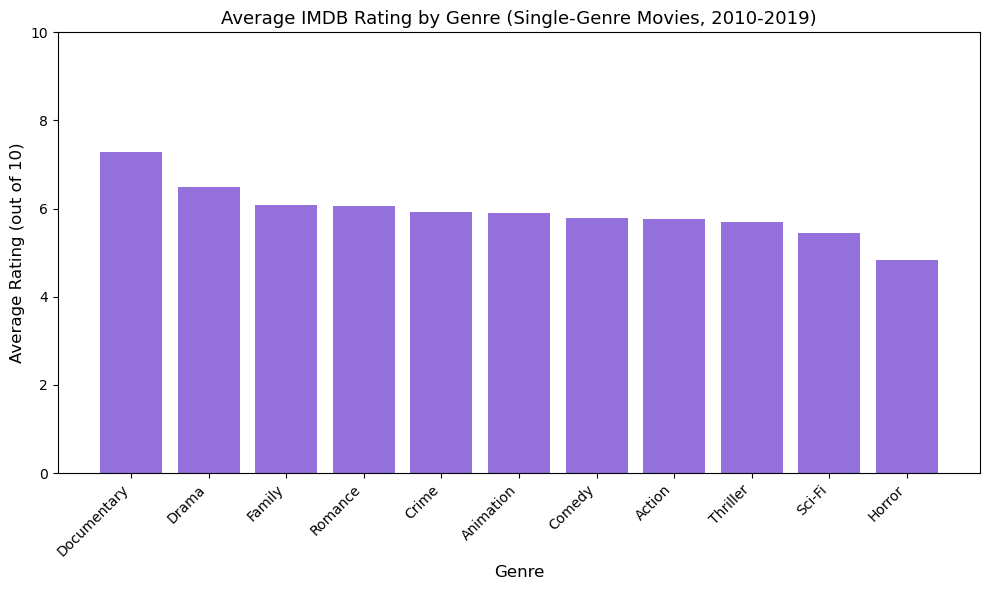

In [184]:
# EXPLORATION 4: Top rated genres - visualization 
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(explore3_df['genres'], explore3_df['avg_rating'], color='mediumpurple')

ax.set_title('Average IMDB Rating by Genre (Single-Genre Movies, 2010-2019)', fontsize=13)
ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Average Rating (out of 10)', fontsize=12)
ax.set_ylim(0, 10)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [185]:
# EXPLORATION 5: Average runtime by genre 
explore5_df = pd.read_sql("""
    SELECT genres,
           ROUND(AVG(runtime_minutes), 1) AS avg_runtime_minutes,
           COUNT(*) AS num_movies
    FROM movie_basics
    WHERE start_year BETWEEN 2010 AND 2019
      AND genres IS NOT NULL
      AND runtime_minutes IS NOT NULL
      AND genres NOT LIKE '%,%'
    GROUP BY genres
    HAVING COUNT(*) > 200
    ORDER BY avg_runtime_minutes DESC
""", conn4)

explore5_df

,genres,avg_runtime_minutes,num_movies
0,Romance,105.8,809
1,Action,102.5,1148
2,Musical,99.8,232
3,Music,98.1,407
4,Mystery,97.2,342
5,Drama,94.9,15705
6,Comedy,93.3,6407
7,Thriller,92.7,1916
8,Crime,91.7,405
9,Adventure,90.5,277


In [186]:
# EXPLORATION 6: Do higher vote counts mean higher ratings? 
# Sample of movies with their vote count and average rating
explore6_df = pd.read_sql("""
    SELECT mb.primary_title, mb.start_year, mb.genres,
           mr.averagerating, mr.numvotes
    FROM movie_basics mb
    JOIN movie_ratings mr ON mb.movie_id = mr.movie_id
    WHERE mb.start_year BETWEEN 2010 AND 2019
      AND mr.numvotes IS NOT NULL
      AND mr.averagerating IS NOT NULL
    ORDER BY mr.numvotes DESC
    LIMIT 20
""", conn4)

print('Top 20 most-voted movies:')
explore6_df

Top 20 most-voted movies:


,primary_title,start_year,genres,averagerating,numvotes
0,Inception,2010,"Action,Adventure,Sci-Fi",8.8,1841066
1,The Dark Knight Rises,2012,"Action,Thriller",8.4,1387769
2,Interstellar,2014,"Adventure,Drama,Sci-Fi",8.6,1299334
3,Django Unchained,2012,"Drama,Western",8.4,1211405
4,The Avengers,2012,"Action,Adventure,Sci-Fi",8.1,1183655
5,The Wolf of Wall Street,2013,"Biography,Crime,Drama",8.2,1035358
6,Shutter Island,2010,"Mystery,Thriller",8.1,1005960
7,Guardians of the Galaxy,2014,"Action,Adventure,Comedy",8.1,948394
8,Deadpool,2016,"Action,Adventure,Comedy",8.0,820847
9,The Hunger Games,2012,"Action,Adventure,Sci-Fi",7.2,795227


In [187]:
# EXPLORATION 7: Data cleaning observations 
# Check for nulls in key columns
null_check_df = pd.read_sql("""
    SELECT
        SUM(CASE WHEN genres IS NULL THEN 1 ELSE 0 END) AS null_genres,
        SUM(CASE WHEN runtime_minutes IS NULL THEN 1 ELSE 0 END) AS null_runtime,
        SUM(CASE WHEN start_year IS NULL THEN 1 ELSE 0 END) AS null_start_year
    FROM movie_basics
    WHERE start_year BETWEEN 2010 AND 2019
""", conn4)

print('Null value counts in movie_basics (2010-2019 movies):')
null_check_df

Null value counts in movie_basics (2010-2019 movies):


,null_genres,null_runtime,null_start_year
0,5359,30765,0


In [188]:
# Close the Part 2 connection
conn4.close()
print('Part 2 connection closed.')

Part 2 connection closed.


## Part 2: Summary of Findings

**Initial Exploration Findings:**

- The dataset contains tens of thousands of movies released between 2010 and 2019 from the IMDB database.
- Documentary is by far the most common single genre in the dataset, followed by Drama and Comedy.
- Average IMDB ratings vary noticeably by genre — Documentary and Drama tend to score higher than Action and Sci-Fi.
- Runtime also varies by genre; some genres (like Biography) tend to have longer average runtimes.
- A significant number of movies are missing runtime data, and genre values are stored as comma-separated strings which complicates grouping.

**Business Question:**

> *Does the genre of a movie influence its average audience rating, and if so, which genres consistently produce the highest-rated films between 2010 and 2019?*

This question is relevant for a studio or streaming platform trying to decide where to invest in new productions or acquisitions.

**Data Cleaning Tasks Identified:**

1. **Genres column normalization** — genres are stored as comma-separated strings (e.g. `'Comedy,Drama,Romance'`). These should be split into individual rows (one genre per row) so grouping and aggregation by genre is accurate.
2. **Null handling in runtime_minutes** — a large number of movies have no runtime recorded. Rows with null runtimes must be excluded from any runtime-based analysis.
3. **Null handling in genres and ratings** — some movies have no genre or no rating and should be excluded from genre/rating analyses.
4. **Excluding post-2019 data** — the instructions note that movies after 2019 are inaccurate/incomplete, so a consistent WHERE filter on start_year is needed throughout the analysis.
5. **Standardizing text fields** — titles and person names may have inconsistent casing or special characters that would need cleaning for any name-matching or deduplication work.